# 14 — Do predicted future features describe future movement?

A useful representation of the observed past and an accurate prediction
of the future are separate achievements. Notebook 10 fits a regression
model from past encoder features to future coordinates. Here we also
examine the feature vector produced by the JEPA predictor itself.

We first fit a small decoder that translates **observed future features**
into landmark positions, using training videos only. We then freeze this
decoder and apply it to **predicted future features** from held-out videos.
Applying the same decoder to observed future features provides a useful
diagnostic: if this easier task fails, the chosen features or decoder
cannot yet express the movement endpoint well enough to judge forecasting.

This notebook depends on the timing and source-separation ideas in
Notebook 10 and the encoder-versus-predictor distinction in Notebook 13.
Its default execution uses a few updates on generated oscillating
landmarks. These outputs are software demonstrations. The real-data
comparison is implemented, but requires explicit enablement and has no
empirical result until it is run and retained.

The retained tables below come from one completed synthetic demonstration:
eight generated clips, six training sources, and two excluded test sources.
Both training conditions use seed 17 and only four optimizer updates. The
twelve-landmark encoder is trained here; the 33-landmark example checks
input preparation and common endpoints without comparing its forecasting
performance. These distinctions matter when interpreting the results.

## 1. State what the forecast can observe

Each example contains the first 0.8 seconds of a clip. A requested horizon
tells the predictor whether to estimate movement 0.25, 0.50, or 0.75
seconds after that boundary. During training, a separate teacher encoder
processes a 0.20-second future window ending at that horizon. Its output
supplies the feature target; its parameters receive no gradient.

The observable outcome is the last measured position in the future
window for twelve specified landmarks. Camera sampling may place this
measurement slightly before or after the requested time. We retain the
actual measurement time in the evaluation record, while predictions
receive only the requested horizon, which is known in advance.

The encoder here follows Notebook 10's small forecasting architecture:
each sampled landmark observation is a token. This is a separately
specified model comparison from the four-step tokens used for masking in
notebooks 11–13. Its optimizer budget alone cannot make it a reproduction
of their training recipe.

In [1]:
from pathlib import Path
from dataclasses import replace
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("svg", "png")

def locate_suite_root():
    for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        for candidate in (parent, parent / "neurips-laterality"):
            if (candidate / "config" / "protocol.json").is_file():
                return candidate
    raise FileNotFoundError("Run within the repository or the laterality folder.")

SUITE_ROOT = locate_suite_root()
if str(SUITE_ROOT) not in sys.path:
    sys.path.insert(0, str(SUITE_ROOT))

from notebook_progress import NotebookTaskProgress, run_real_future_comparison_with_progress
from laterality_extensions.forecasting import JOINTS, TimedPose, synthetic_records
from laterality_extensions.future_comparison import (
    ALL_JOINTS, ComparisonForecastSpec, ForecastComparisonModel,
    aggregate_future_error_rows, forecast_configuration, forecast_error_rows,
    plan_future_comparison, prepare_future_examples, prepare_prefix,
    real_forecast_spec, run_future_comparison, run_real_future_comparison,
)

torch.set_num_threads(1)
tutorial_progress = NotebookTaskProgress(
    "Future-feature movement prediction tutorial", unit_name="stage",
)
tutorial_progress.start(
    11, profile="synthetic demonstration with optional real-data run",
    note="Tracking leakage checks, model fits, evaluation, and the optional real grid",
)
synthetic_spec = ComparisonForecastSpec(updates=4)
print("SYNTHETIC SOFTWARE DEMONSTRATION — no empirical gait result")
display(pd.Series(forecast_configuration(synthetic_spec), name="Demonstration settings").to_frame())

SYNTHETIC SOFTWARE DEMONSTRATION — no empirical gait result


,Demonstration settings
context_seconds,0.8
horizons,"(0.25, 0.5, 0.75)"
future_window_seconds,0.2
samples,8
max_past_age,0.2
target_time_tolerance,0.055
visibility_threshold,0.45
embed_dim,8
updates,4
batch_size,4


## 2. Follow the two evaluation routes

The lower row in the following diagram uses an observed future window,
so it has access to the answer period. It tests whether the frozen
representation and training-only decoder can express the measured
coordinates. The upper row is the forecast: every value available to
the context encoder comes from the observed prefix.

Both routes use the same decoder and the same measured endpoints. A
large gap between their errors can arise when predicted features lie
outside the distribution on which the decoder was fitted. A decoder
applied to such features may extrapolate badly even when its observed-
future diagnostic is accurate. This is a substantive outcome to report.

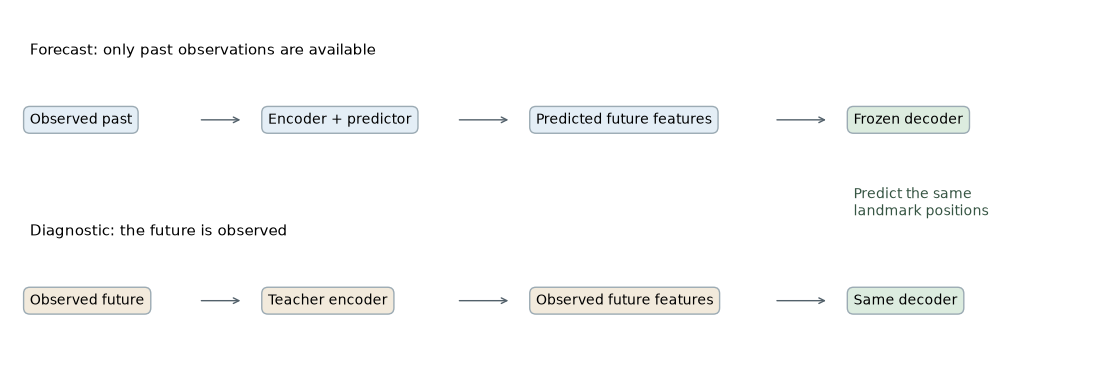

In [2]:
with tutorial_progress.unit(1, "Render the forecasting workflow"):
    fig, ax = plt.subplots(figsize=(11, 3.7), constrained_layout=True)
    ax.set(xlim=(0, 11), ylim=(-0.5, 3.1))
    ax.axis("off")
    boxes = [
        (0.2, 2.0, "Observed past", "#e4eef6"),
        (2.6, 2.0, "Encoder + predictor", "#e4eef6"),
        (5.3, 2.0, "Predicted future features", "#e4eef6"),
        (8.5, 2.0, "Frozen decoder", "#dcecdf"),
        (0.2, 0.2, "Observed future", "#f2eadc"),
        (2.6, 0.2, "Teacher encoder", "#f2eadc"),
        (5.3, 0.2, "Observed future features", "#f2eadc"),
        (8.5, 0.2, "Same decoder", "#dcecdf"),
    ]
    for x, y, label, color in boxes:
        ax.text(x, y, label, ha="left", va="center", fontsize=10,
                bbox={"boxstyle": "round,pad=0.45", "fc": color, "ec": "#9cabb4"})
    for y in (2.0, 0.2):
        for left, right in ((1.9, 2.35), (4.5, 5.05), (7.7, 8.25)):
            ax.annotate("", (right, y), (left, y), arrowprops={"arrowstyle": "->", "color": "#53616b"})
    ax.text(0.2, 2.65, "Forecast: only past observations are available", fontsize=11)
    ax.text(0.2, 0.85, "Diagnostic: the future is observed", fontsize=11)
    ax.text(8.5, 1.05, "Predict the same\nlandmark positions", fontsize=10, color="#365543")
    display(fig)
    plt.close(fig)

## 3. Prepare both input choices with common endpoints

A separate configuration supplies either twelve gait landmarks or all 33
landmarks to the encoder. In both cases, the measured future coordinates
remain the same twelve landmarks: shoulders, hips, knees, ankles, heels,
and foot tips. The twelve-landmark prefix also determines eligibility,
the pelvis reference position, and body scale in both configurations.

This keeps a change in input coverage from silently changing the target
or accepted clip set. The all-landmark configuration therefore still
retains anatomical choices in its normalization and endpoint. Its joint
identity table has the same parameter shape as the twelve-input model,
allowing initial weights to be paired while the visible input changes.

The sampler keeps the most recent valid observation at or before each
past query time, provided it is sufficiently recent. It records that
observation's actual time. No interpolation between a past observation
and a future observation enters the context.

In [3]:
with tutorial_progress.unit(2, "Prepare matched synthetic forecasting examples"):
    records = synthetic_records(sources=8, clips_per_source=1)
    examples = prepare_future_examples(records, synthetic_spec, status="SYNTHETIC DEMONSTRATION")
    all_input_examples = prepare_future_examples(
        records, replace(synthetic_spec, input_joints=ALL_JOINTS),
        status="SYNTHETIC DEMONSTRATION",
    )
    for field in ("endpoint", "endpoint_valid", "endpoint_times", "sequence_ids", "horizon"):
        np.testing.assert_array_equal(getattr(examples, field), getattr(all_input_examples, field))
    display(pd.DataFrame([
        {"Input landmarks": len(data.input_joints), "Future endpoints": data.endpoint.shape[1],
         "Clips": data.coverage["accepted_clips"], "Sources": data.coverage["sources"],
         "Clip–horizon examples": data.coverage["examples"]}
        for data in (examples, all_input_examples)
    ]))

,Input landmarks,Future endpoints,Clips,Sources,Clip–horizon examples
0,12,12,8,8,24
1,33,12,8,8,24


Both input choices retain the same eight generated clips and 24
clip–horizon examples, with twelve measured endpoints per example. The
24 examples ask three future questions about each of the same eight
clips. They are not 24 independent movement sources. The equality checks
confirm that adding input landmarks has preserved the target coordinates,
measurement times, and visibility for this comparison. Whether the larger
input helps prediction remains untested by these rows.

In real recordings, unavailable future endpoints
affect evaluation coverage even when the context remains valid, so their
exclusions must accompany the prediction scores.

## 4. Check the information boundary directly

We now replace every coordinate after the observation boundary, remove
its visibility, and move its timestamp further into the future. Since all
changed timestamps remain after the boundary, the prepared prefix and
deterministic forecast should remain unchanged. Moving a measurement
across the boundary would change the observations available and would
answer a different question.

In [4]:
with tutorial_progress.unit(3, "Run the no-future-leakage check"):
    record = records[0]
    later = record.times - record.times[0] > synthetic_spec.context_seconds + 1e-10
    changed_xyz, changed_valid, changed_times = record.xyz.copy(), record.valid.copy(), record.times.copy()
    changed_xyz[later], changed_valid[later] = 1e6, False
    changed_times[later] += 0.4
    changed = TimedPose(record.source, record.sequence_id, changed_times, changed_xyz, changed_valid)
    original_prefix = prepare_prefix(record, synthetic_spec)
    changed_prefix = prepare_prefix(changed, synthetic_spec)
    for field in original_prefix:
        np.testing.assert_array_equal(original_prefix[field], changed_prefix[field])

    torch.manual_seed(synthetic_spec.seed)
    initial_model = ForecastComparisonModel(synthetic_spec).eval()
    def predict_from_prefix(prefix):
        with torch.no_grad():
            return initial_model.predict(
                torch.tensor(prefix["xyz"])[None], torch.tensor(prefix["valid"])[None],
                torch.tensor(prefix["times"])[None], torch.tensor([0.25]),
            )
    torch.testing.assert_close(predict_from_prefix(original_prefix), predict_from_prefix(changed_prefix), rtol=0, atol=0)
    print("Changed future coordinates, visibility, and later timestamps leave context and prediction unchanged.")

Changed future coordinates, visibility, and later timestamps leave context and prediction unchanged.


The preceding check passed: replacing future coordinates and visibility,
and moving future observations to later timestamps, left the prepared
context and deterministic prediction unchanged. This verifies the tested
information boundary. Forecast accuracy still needs the comparisons below.

## 5. Fit matched and mismatched future targets

The small model encodes the prefix, appends the requested horizon, and
predicts the teacher's future feature vector. Its loss combines mean
squared feature error with a penalty on very low context variation.
The variance term encourages nonconstant features; measured variation
and movement prediction must still be checked afterward.

The control receives a future window from a different training video at
the same horizon. It samples an eligible video uniformly before sampling
a clip from that video. A separate random stream for this mismatch keeps
the two arms' initial weights, context draws, and update counts paired.
This control asks whether the correct temporal pairing helps beyond the
exposure to generic future windows.

The online encoder, teacher, and predictor are retained separately at
the final, prespecified update. Teacher features are evaluated with their
own frozen readout; the forecasting predictor always receives online
context features through its normal pathway.

In [5]:
with tutorial_progress.unit(4, "Run the matched synthetic forecasting comparison"):
    source_names = sorted(set(examples.sources))
    training_sources, testing_sources = source_names[:6], source_names[6:]
    assert not set(training_sources) & set(testing_sources)
    comparison = run_future_comparison(
        examples, synthetic_spec,
        train_sources=training_sources, test_sources=testing_sources,
    )
    assert comparison["matched"]["source_schedule"] == comparison["mismatched"]["source_schedule"]
    display(pd.DataFrame([
        {"Training target": label, "Updates": len(comparison[key]["history"]),
         "Training sources": len(comparison[key]["train_sources"]),
         "Training time (seconds)": comparison[key]["runtime_seconds"]}
        for key, label in (("matched", "Matching future"), ("mismatched", "Another source's future"))
    ]).style.format({"Training time (seconds)": "{:.2f}"}))

,Training target,Updates,Training sources,Training time (seconds)
0,Matching future,4,6,0.01
1,Another source's future,4,6,0.01


The completed fit used six generated training sources and four updates
for each condition. The recorded source-schedule equality check passed,
so the mismatched-future control received the same context examples.
This short execution tests the comparison machinery; it is insufficient
for deciding whether either training objective can learn useful dynamics.

## 6. Fit decoders within the training videos

Each coordinate decoder uses a linear regression with a penalty that
limits large coefficients. The training videos are divided into inner
source groups to choose that penalty. Scaling and regression fitting use
only the inner training group for each validation split; the final
decoder is then fitted on all outer training videos. Each video receives
equal total weight, regardless of its number of clips.

This inner procedure selects a supervised readout for an already fixed
encoder. It does not validate the entire pretraining recipe: the encoder
was pretrained on all outer training videos, including videos later used
for readout validation. Comparing pretraining recipes through inner
validation would also require excluding those inner validation videos
from candidate encoder training.

The future-feature decoder sees observed future-teacher features and
future coordinates from training videos. After fitting, the same
coefficients translate both observed and predicted future features from
test videos. The requested horizon and its interaction with features are
supplied consistently to all fitted readouts. Actual future measurement
times and visibility are used for scoring, without entering the forecast.

In [6]:
with tutorial_progress.unit(5, "Inspect the training-only frozen decoder"):
    decoder = comparison["decoders"]["Matched future-feature decoder"]
    assert set(decoder.fitted_sources) == set(training_sources)
    assert not set(decoder.fitted_sources) & set(testing_sources)
    display(pd.DataFrame({
        "Landmark": ["Left shoulder", "Right shoulder", "Left hip", "Right hip",
                     "Left knee", "Right knee", "Left ankle", "Right ankle",
                     "Left heel", "Right heel", "Left foot tip", "Right foot tip"],
        "Ridge penalty selected within training videos": decoder.selected_alphas,
    }))

,Landmark,Ridge penalty selected within training videos
0,Left shoulder,0.1
1,Right shoulder,0.1
2,Left hip,0.1
3,Right hip,0.1
4,Left knee,0.1
5,Right knee,0.1
6,Left ankle,0.1
7,Right ankle,0.1
8,Left heel,0.1
9,Right heel,0.1


The training-source validation selected a ridge penalty of 0.1 for all
twelve decoder endpoints, from the two candidates 0.1 and 10.0. This
records how the decoder was selected within this small example. It does
not establish 0.1 as a generally suitable penalty for gait forecasting.

## 7. Read the result by the question it answers

The first table compares the two future-feature routes. The observed-
future diagnostic has access to future information; its error describes
how well the learned features and decoder express the endpoint. The
predicted-future row is the actual forecast. The mismatched-future rows
test whether correct temporal pairing mattered in the same setup.

Errors are in the body-width scale estimated from the prefix, using the
pose model's coordinate channels. They are not distances in millimeters
or validated anatomical measurements. For each requested horizon, we
average coordinate error over common observed landmarks in each clip,
give every test video equal total weight, and then take the square root.

In [7]:
with tutorial_progress.unit(6, "Summarize decoded future-feature errors"):
    scores = comparison["scores"]
    decoded_rows = scores[scores.method.str.contains("future features decoded", regex=False)]
    print("SYNTHETIC RESULTS — source-balanced coordinate RMSE; lower is better")
    display(decoded_rows.pivot(index="method", columns="horizon_seconds", values="source_balanced_rmse").style.format("{:.3f}"))

SYNTHETIC RESULTS — source-balanced coordinate RMSE; lower is better


horizon_seconds,0.250000,0.500000,0.750000
method,,,
Matched: observed future features decoded (diagnostic),0.011,0.013,0.025
Matched: predicted future features decoded,2.507,2.611,2.637
Mismatched: observed future features decoded (diagnostic),0.011,0.013,0.025
Mismatched: predicted future features decoded,2.507,2.611,2.637


The two routes produce very different errors in this execution. Decoding
observed future features gives RMSE from 0.011 to 0.025 across the three
horizons; decoding predicted future features gives about 2.51 to 2.64.
For example, at the requested 0.50-second horizon, the same frozen
decoder has error 0.013 when given observed future features and about
2.61 when given predicted features. The features of the observed future
can therefore express these endpoints through this decoder, while the
predicted features cannot yet support accurate coordinate forecasts.
The teacher sees the observed future positions, so its good decoder
score alone does not establish that pretraining has learned movement
dynamics.

This result directs attention to future-feature prediction and its
compatibility with the decoder's training distribution. It does not
identify a single cause or show that the same problem persists after
substantive training. Both models have received only four updates.

The matched- and mismatched-future rows agree at the displayed precision
at every horizon. Correct temporal pairing has therefore shown no clear
benefit in this demonstration. Rounded agreement in one small run cannot
establish that the objectives are equivalent or that future-target
learning is ineffective.

The next table evaluates other routes from the same past observations.
Regression from the trained past encoder answers Notebook 10's original
question. Direct-coordinate regression checks whether an encoder adds
useful information processing beyond the available pose data. The initial
encoder controls for architectural features that exist before pretraining.
Last-position and recent-velocity forecasts provide simple movement
references, using the requested horizon and past observations only.

In [8]:
with tutorial_progress.unit(7, "Compare baselines and verify prediction coverage"):
    past_rows = scores[~scores.method.str.contains("future features decoded", regex=False)]
    display(past_rows.pivot(index="method", columns="horizon_seconds", values="source_balanced_rmse").style.format("{:.3f}"))
    display(comparison["prediction_coverage"])
    timing = scores[["horizon_seconds", "actual_time_min", "actual_time_max", "test_sources", "test_clips", "common_endpoints"]].drop_duplicates()
    display(timing.style.format({"horizon_seconds": "{:.2f}", "actual_time_min": "{:.3f}", "actual_time_max": "{:.3f}"}))

horizon_seconds,0.250000,0.500000,0.750000
method,,,
Initial past encoder with regression,0.063,0.069,0.074
Last observed position,0.086,0.155,0.143
Mismatched-future past encoder with regression,0.064,0.068,0.072
Past coordinates with regression,0.077,0.057,0.059
Past teacher with regression,0.063,0.069,0.074
Recent velocity continuation,0.088,0.216,0.301
Trained past encoder with regression,0.064,0.068,0.072


,method,horizon_seconds,requested_examples,observed_endpoints,unavailable_predictions,common_endpoints,examples_without_common_endpoints
0,Last observed position,0.25,2,24,0,24,0
1,Recent velocity continuation,0.25,2,24,0,24,0
2,Past coordinates with regression,0.25,2,24,0,24,0
3,Initial past encoder with regression,0.25,2,24,0,24,0
4,Trained past encoder with regression,0.25,2,24,0,24,0
5,Past teacher with regression,0.25,2,24,0,24,0
6,Mismatched-future past encoder with regression,0.25,2,24,0,24,0
7,Matched: predicted future features decoded,0.25,2,24,0,24,0
8,Matched: observed future features decoded (dia...,0.25,2,24,0,24,0
9,Mismatched: predicted future features decoded,0.25,2,24,0,24,0


,horizon_seconds,actual_time_min,actual_time_max,test_sources,test_clips,common_endpoints
0,0.25,0.250,0.267,2,2,24
11,0.50,0.500,0.533,2,2,24
22,0.75,0.733,0.750,2,2,24


The past-feature results answer a narrower question than the decoded
forecasts. At 0.50 seconds, regression from the trained past encoder has
RMSE 0.068, compared with 0.069 for its initial encoder and 0.057 for
direct past-coordinate regression. At 0.25 seconds the initial encoder
is better than direct coordinates, while direct coordinates are better
at 0.75 seconds. The small differences between trained and initial
features change direction across horizons. There is no consistent
pretraining advantage across these toy comparisons, and the matched and
mismatched past-encoder readouts also agree to the displayed precision.

Recent-velocity continuation becomes less accurate at longer horizons:
its error rises from about 0.088 to 0.301. These generated trajectories
oscillate, so continuing the latest velocity can overshoot a movement
that is about to reverse. The result explains why a simple motion
reference belongs in the comparison, without establishing that a JEPA
has learned those reversals.

Every method is evaluated on the same two excluded clips and all 24
landmark endpoints at each horizon, with no unavailable predictions.
Unequal endpoint coverage therefore does not explain the error gap in
this execution. The requested 0.50-second forecast is compared with
measurements taken 0.500–0.533 seconds after the boundary; the timing
table makes that sampling difference visible. The three horizons still
reuse the same two test sources.

The retained error rows also support an explicitly declared collection
of outer folds. Aggregation first pools each seed's clip predictions at
a given horizon and then computes its source-balanced error. It rejects
duplicate predictions, overlapping test-video groups, missing declared
examples, changed coordinate targets, and mismatched endpoint coverage.
A partial summary must be requested explicitly and carries that label.

The following check uses this tutorial's single synthetic split. It
confirms that pooled scoring reproduces the previously displayed errors;
it does not manufacture additional folds or training seeds. Saved real
runs can be converted with `saved_forecast_error_rows` and combined against
the expected clip, video, fold, and horizon manifest. The
`paired_future_source_interval` helper then keeps every video's clip and
seed predictions together when resampling source videos.

In [9]:
with tutorial_progress.unit(8, "Verify source-balanced aggregation"):
    test_rows = comparison["test_indices"]
    error_rows = forecast_error_rows(
        {method: values[test_rows] for method, values in comparison["predictions"].items()},
        sources=examples.sources[test_rows], sequence_ids=examples.sequence_ids[test_rows],
        horizon=examples.horizon[test_rows], target=examples.endpoint[test_rows],
        valid=examples.endpoint_valid[test_rows], seed=synthetic_spec.seed, fold=0, input_landmarks=12,
        actual_times=examples.endpoint_times[test_rows], checkpoint="final", updates=synthetic_spec.updates,
    )
    expected = error_rows[["sequence_id", "source_id", "fold", "horizon_seconds"]].drop_duplicates()
    aggregated = aggregate_future_error_rows(
        error_rows, expected, seeds=(synthetic_spec.seed,), input_sizes=(12,),
        methods=tuple(comparison["predictions"]),
    )
    order = ["method", "horizon_seconds"]
    np.testing.assert_allclose(
        aggregated["per_seed"].sort_values(order).source_balanced_rmse,
        scores.sort_values(order).source_balanced_rmse,
    )
    print("Pooling preserves the measured errors for this one declared synthetic split and seed.")

Pooling preserves the measured errors for this one declared synthetic split and seed.


The aggregation check reproduced the displayed errors for this one
synthetic split and seed. It verifies the scoring calculation, without
adding independent evidence about generalization or uncertainty. Any
real-data comparison between input choices must also preserve the
endpoint agreement and report its actual source coverage.

A low teacher-feature error alone cannot rank the methods. Each arm has
its own learned teacher, and a teacher with less variable features can
make prediction easier. The normalized error below divides mean squared
feature error by the mean coordinate-wise variance of that arm's target
features. This makes the denominator explicit, but does not turn
different teachers into a common measurement scale.

In [10]:
with tutorial_progress.unit(9, "Inspect feature and latent diagnostics"):
    display(comparison["feature_diagnostics"].style.format({
        "mean_feature_std": "{:.3g}", "effective_rank": "{:.2f}", "mean_feature_norm": "{:.3g}",
    }))
    display(pd.DataFrame(comparison["latent_diagnostics"]).drop(columns="scope").style.format({
        "feature_mse": "{:.3g}", "target_variance_denominator": "{:.3g}", "normalized_error": "{:.3g}",
    }))

,arm,feature,mean_feature_std,effective_rank,mean_feature_norm,weighting,status
0,Matched,past_online,0.00809,1.00,2.41,"Equal total weight per video, across its clip-horizon examples",Variation present; movement usefulness needs its own score
1,Matched,past_teacher,0.0088,1.00,2.46,"Equal total weight per video, across its clip-horizon examples",Variation present; movement usefulness needs its own score
2,Matched,future_teacher,0.101,1.21,2.53,"Equal total weight per video, across its clip-horizon examples",Variation present; movement usefulness needs its own score
3,Matched,predicted_future,0.0072,1.18,0.339,"Equal total weight per video, across its clip-horizon examples",Variation present; movement usefulness needs its own score
4,Mismatched,past_online,0.00809,1.00,2.41,"Equal total weight per video, across its clip-horizon examples",Variation present; movement usefulness needs its own score
5,Mismatched,past_teacher,0.0088,1.00,2.46,"Equal total weight per video, across its clip-horizon examples",Variation present; movement usefulness needs its own score
6,Mismatched,future_teacher,0.101,1.21,2.53,"Equal total weight per video, across its clip-horizon examples",Variation present; movement usefulness needs its own score
7,Mismatched,predicted_future,0.0072,1.18,0.339,"Equal total weight per video, across its clip-horizon examples",Variation present; movement usefulness needs its own score


,arm,feature_mse,target_variance_denominator,normalized_error
0,Matched,0.732,0.0128,57.3
1,Mismatched,0.732,0.0128,57.3


The feature diagnostics help explain why the decoded forecasts need
further work. Predicted future features have average norm about 0.34,
compared with 2.53 for observed future-teacher features. Their average
feature variation is also smaller, about 0.0072 versus 0.10. The
predictor's outputs therefore differ substantially in scale and
variation from the features used to fit the decoder. This is consistent
with poor decoding of those predictions, although it does not isolate
which aspect of the mismatch causes the coordinate error.

The normalized feature error is about 57: the prediction's mean squared
error is about 57 times the variance used as its denominator. This is a
diagnostic ratio, rather than an accuracy percentage. It also cannot
rank usefulness across models with different learned teachers.

The past-feature effective rank of 1 needs special care. There are only
two distinct test prefixes, each reused at three horizons, so their
centered feature vectors can span at most one direction. Repeating a
prefix at different requested horizons does not add a new past-encoder
feature vector. This rank therefore cannot establish representation
collapse; broader, independent inputs are needed for that diagnosis.

## 8. Review a complete real-data workload before training

The explicit real-data recipe below uses 1,200 updates, a 24-dimensional
encoder, and a batch size of eight. These are declared starting settings
for this separate forecasting task. The architecture and future-feature
objective differ from Notebook 08, even though its update count provides
a useful scale reference. A change in training budget should be justified
from training sources and applied consistently to compared methods.

Five existing outer video groups and five seeds produce 25 paired runs
for the twelve-input configuration, containing 50 fitted forecasting
models. Supplying both input sets is a separate, explicit comparison that
doubles this workload. Decoder fits are additional supervised readouts.
A smaller selection of folds or seeds is labeled as a pilot or partial
comparison, with its actual scope retained.

The first cell only displays the complete plan. The following cell can
validate raw recordings and existing source assignments without training.
Setting the training flag enables the requested runs after the plan is
displayed. Completed compatible outputs are reused; existing incompatible,
corrupted, or incomplete outputs fail clearly. Interrupted training is
recorded as incomplete and has no automatic resume path.

In [11]:
with tutorial_progress.unit(10, "Plan the real-data forecasting grid"):
    real_spec = real_forecast_spec()
    REAL_FOLDS = (0, 1, 2, 3, 4)
    REAL_SEEDS = (42, 43, 44, 45, 46)
    REAL_INPUT_SETS = (JOINTS,)  # Add ALL_JOINTS only for the declared input comparison.
    REAL_OUTPUT_ROOT = SUITE_ROOT / "outputs" / "masking_extensions" / "future"
    workload = plan_future_comparison(
        real_spec, folds=REAL_FOLDS, seeds=REAL_SEEDS,
        input_sets=REAL_INPUT_SETS, output_root=REAL_OUTPUT_ROOT,
    )
    display(pd.DataFrame(workload["runs"]))
    display(pd.Series(workload["recipe"], name="Real-data recipe").to_frame())
    print(f'{workload["scope"]}: {workload["model_fits"]} forecasting model fits, '
          f'{workload["optimizer_updates"]:,} updates, '
          f'{workload["source_example_draws"]:,} source-balanced example draws.')
    print(workload["recipe_note"])

,fold,seed,input_landmarks,conditions,updates_per_model,output
0,0,42,12,"[Matched future, Mismatched future]",1200,/Users/pmui/dev/alexpose/experiments/sjepa/gav...
1,0,43,12,"[Matched future, Mismatched future]",1200,/Users/pmui/dev/alexpose/experiments/sjepa/gav...
2,0,44,12,"[Matched future, Mismatched future]",1200,/Users/pmui/dev/alexpose/experiments/sjepa/gav...
3,0,45,12,"[Matched future, Mismatched future]",1200,/Users/pmui/dev/alexpose/experiments/sjepa/gav...
4,0,46,12,"[Matched future, Mismatched future]",1200,/Users/pmui/dev/alexpose/experiments/sjepa/gav...
5,1,42,12,"[Matched future, Mismatched future]",1200,/Users/pmui/dev/alexpose/experiments/sjepa/gav...
6,1,43,12,"[Matched future, Mismatched future]",1200,/Users/pmui/dev/alexpose/experiments/sjepa/gav...
7,1,44,12,"[Matched future, Mismatched future]",1200,/Users/pmui/dev/alexpose/experiments/sjepa/gav...
8,1,45,12,"[Matched future, Mismatched future]",1200,/Users/pmui/dev/alexpose/experiments/sjepa/gav...
9,1,46,12,"[Matched future, Mismatched future]",1200,/Users/pmui/dev/alexpose/experiments/sjepa/gav...


,Real-data recipe
context_seconds,0.8
horizons,"(0.25, 0.5, 0.75)"
future_window_seconds,0.2
samples,8
max_past_age,0.2
target_time_tolerance,0.055
visibility_threshold,0.45
embed_dim,24
updates,1200
batch_size,8


Complete declared comparison: 50 forecasting model fits, 60,000 updates, 480,000 source-balanced example draws.
Separate forecasting architecture and objective; the 1,200-update setting does not reproduce Notebook 08's training recipe.


In [12]:
VALIDATE_REAL_INPUTS = False
ENABLE_REAL_TRAINING = False
if ENABLE_REAL_TRAINING:
    real_progress = NotebookTaskProgress(
        "Real future-feature comparison", unit_name="job",
    )
    with tutorial_progress.unit(11, "Run the optional real-data forecasting grid"):
        real_request = run_real_future_comparison_with_progress(
            progress=real_progress, enabled=True, validate_inputs=VALIDATE_REAL_INPUTS,
            spec=real_spec, folds=REAL_FOLDS, seeds=REAL_SEEDS,
            input_sets=REAL_INPUT_SETS, output_root=REAL_OUTPUT_ROOT,
        )
        print(real_request["status"])
elif VALIDATE_REAL_INPUTS:
    with tutorial_progress.unit(11, "Validate the optional real-data inputs"):
        real_request = run_real_future_comparison(
            enabled=False, validate_inputs=True,
            spec=real_spec, folds=REAL_FOLDS, seeds=REAL_SEEDS,
            input_sets=REAL_INPUT_SETS, output_root=REAL_OUTPUT_ROOT,
        )
        print(real_request["status"])
else:
    tutorial_progress.start_unit(11, "Run the optional real-data forecasting grid")
    tutorial_progress.skip_unit("Real-data input loading and training remain disabled")
    print("Real-data plan displayed. Input loading and training remain disabled.")

tutorial_progress.complete(
    status="Tutorial complete" if ENABLE_REAL_TRAINING
    else "Tutorial complete · optional real-data training not run"
)

Real-data plan displayed. Input loading and training remain disabled.


The final execution message confirms that real-data input loading and
training were disabled. The 50 model fits and 60,000 updates above are
a planned workload, not completed experiments. One formatting detail
also needs clarification: the generic settings table displays the
optimizer epsilon as 0.0, while the declared AdamW setting is 1e-8.
The display has rounded a small nonzero constant.

## 9. What would support useful future-feature learning?

A persuasive result would combine an informative observed-future decoder
diagnostic with accurate decoded predicted features on excluded videos.
The predicted-feature route should be compared with direct past-coordinate
regression, initial features, simple motion references, and the same
architecture trained against mismatched futures. If correct temporal
pairing has no clear benefit, the experiment has not established that
the learned future association improves the observable forecast.

Repeated seeds reuse the same recordings. For a full comparison, combine
each seed's out-of-fold predictions before reporting its source-balanced
score, and summarize seed variability separately. Paired intervals should
resample whole source videos with all their clip, horizon, condition, and
seed predictions together; they describe uncertainty conditional on the
fitted models, rather than the uncertainty of retraining everything.

Future-target learning has substantial prior work. The August 2026
[Human-JEPA preprint](https://arxiv.org/html/2608.21160v1) studies strictly
past-to-future masks in human video and evaluates the role of the predictor
head. Our small pose model is a separate implementation; it does not
reproduce that model's pretraining, scale, or reported results. The useful
research question here is whether a carefully controlled future-feature
pathway improves measured movement prediction under source separation.

The present execution demonstrates a useful way to locate a failure:
observed future features can be decoded accurately, but the predicted
features produce poor coordinate forecasts after four training updates.
Its past-feature readouts also give no consistent improvement over the
initial encoder, and correct future pairing has no clear advantage at
the displayed precision. These findings concern this generated example
and provide a reason to keep the controls in a substantive experiment.

This notebook has not compared future-only training with interior-gap
completion or the scattered and anatomical masks in notebooks 11–13.
It therefore cannot rank those masking policies or determine whether
twelve or 33 input landmarks are better for forecasting. Real gait
forecasting remains unmeasured by the retained outputs. The three
horizons are separate forecasts from one shared prefix, not statistically
independent tests or a recursive rollout. A rollout would require a
tested transition from one predicted state to the next.